# Pràctica Bloc III

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import zip_longest
from sklearn.preprocessing import StandardScaler, OneHotEncoder

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# Neteja i transformació de les dades

La primera columna que podem eliminar que no ens aporta absolutament res és `Unnamed: 0`, que és un identificador de les dades.

In [98]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


Una cosa important a tenir en compte és eliminar les dades invàlides ja que qualsevol operació amb una `NaN` (*Not a Number*) resultarà amb un altre `NaN`. Per fer-ho, la forma més intuitiva és veure quines columnes tenen aquests valors.

In [99]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

En aquest cas, l'única columna que conté valors `NaN` és "Arrival Delay in Minutes". Per a no perdre les 393 entrades de dades el que podem fer és reemplaçar cada un d'aquests valors invàlids amb la mitjana de tota la columna.

In [100]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

També és molt important analitzar quin tipus de dades té cada columna. En aquest cas es poden separar en tres tipus:

* Dades categòriques
* Dades de nivell de satisfacció (valors en el rang $[0, 5]$)
* Dades numèriques

In [101]:
# columnes amb nivells de satisfacció [0, 5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# obtenir les columnes sense valors numèrics -> columnes categòriques
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# obtenir les columnes amb valor numèrics
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
# llevam les columnes de nivel de satisfacció per a tenir-ho organitzat en tres tipus 
numcols ^= lvlcols

numcols, lvlcols, catcols = map(list, (numcols, lvlcols, catcols))

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
catvals = { col: list(train_raw[col].unique()) for col in catcols }
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    satisfaction   : ['neutral or dissatisfied', 'satisfied']
    Class          : ['Eco Plus', 'Business', 'Eco']
    Gender         : ['Male', 'Female']
    Customer Type  : ['Loyal Customer', 'disloyal Customer']
    Type of Travel : ['Personal Travel', 'Business travel']
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Inflight wifi service
    Gate location
    Online boarding
    Seat comfort
    Departure/Arrival time convenient
    Inflight service
    Inflight entertainment
    Baggage handling
    Checkin service
    Ease of Online booking
    Leg room service
    Cleanliness
    Food and drink
    On-board service
--------------------------------------------------------------------------------
Columns with numeric values
    Departure Delay in Minutes
    Flight Distance
    Age
    Arrival Delay in Minutes


Degut a que els models no poden processar dades categòriques, és imprescindible transformar-les a dades numèriques. Per fer-ho podem utilitzar `OneHotEncoder` de scikit-learn que crea una columna nova per a cada categoria de cada columna i li assigna el valor 1 quan apareix la categoria i un 0 quan no.

Per intentar reduïr el nombre de columnes podem assignar el paràmetre `drop="if_binary"` que només crearà una columna quan només hi ha dues categories (per exèmple, el sexe del viatger). D'aquesta forma, un 1 indica la classe positiva (la que apareix al nom de la columna resultant) i un 0 la classe negativa.

In [102]:
trgcol = "satisfaction"
trgmap = {"neutral or dissatisfied": 0, "satisfied": 1}

enc = OneHotEncoder(drop="if_binary", sparse_output=False).set_output(transform="pandas")

cat_train = enc.fit_transform(train_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_train = pd.concat([train_raw.drop(columns=catcols), cat_train], axis=1)
y_train = train_raw[trgcol].map(trgmap)

cat_test = enc.transform(test_raw[catcols].drop(columns=[trgcol], errors='ignore'))
X_test = pd.concat([test_raw.drop(columns=catcols), cat_test], axis=1)
y_test = test_raw[trgcol].map(trgmap)
X_test = X_test[X_train.columns] # assegurar que train i test tenguin el mateix ordre de les columnes

X_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,13,460,3,4,3,1,5,3,5,5,...,5,5,25,18.0,0.0,0.0,1.0,1.0,0.0,1.0
1,25,235,3,2,3,3,1,3,1,1,...,4,1,1,6.0,1.0,0.0,0.0,1.0,1.0,0.0
2,26,1142,2,2,2,2,5,5,5,5,...,4,5,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,25,562,2,5,5,5,2,2,2,2,...,4,2,11,9.0,1.0,0.0,0.0,0.0,0.0,0.0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Anàlisi

Per a poder realitzar un anàlisi de les dades ens ajudarà molt poder reduïr el nombre de columnes. Com que tenim moltes columnes de nivell de satisfacció, 14 en total, potser en poguem agrupar unes quantes que s'assemblin bastant. Per fer-ho, generam una matriu de correlació i analitzam quines de les columnes es relacionen amb les altres.

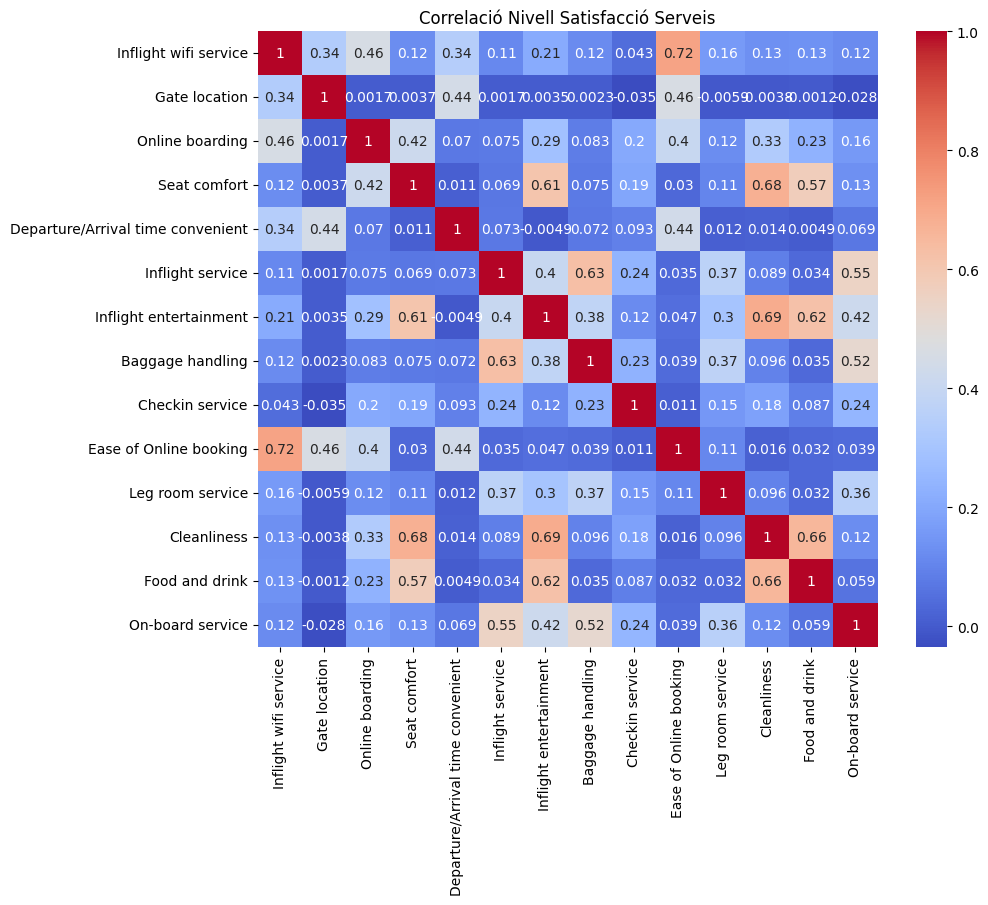

In [103]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[lvlcols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlació Nivell Satisfacció Serveis")
plt.show()

Com es pot observar a la matriu de correlació, diverses variables presenten una dependència estadística notable, amb coeficients que oscil·len entre el 60% i el 70%. Tot i que inicialment podria semblar beneficiós fusionar aquestes columnes per reduir la dimensionalitat, aquesta decisió no sempre és la més adequada. En molts casos, aquestes correlacions no responen a una identitat real entre les variables, sinó a l'efecte Halo: un biaix cognitiu on la percepció positiva d'una característica predominant eleva artificialment la valoració de les altres.

Per exemple, la variable *Cleanliness* presenta una correlació forta amb *Seat comfort* (0.68) i *Inflight entertainment* (0.69). Des del punt de vista del passatger, un entorn net genera una sensació de benestar que pot enmascarar deficiències en la comoditat del seient o en la qualitat del contingut multimèdia. Mantenir-les com a variables independents ens permet analitzar si l'aerolínia ha de realitzar inversions diferenciades —manteniment versus tecnologia— en lloc d'assumir que ambdues experiències són indestriables.

Les columnes de nivell de satisfacció es poden agrupar calculant la mitjana de cada grup:

| Columna original                                                   | Grup     |
|--------------------------------------------------------------------|----------|
| Baggage handling<br>Checkin service<br>Inflight service            | Logistic |
| Seat comfort<br>Leg room service<br>On-board service               | Comfort  |
| Ease of Online booking<br>Inflight wifi service<br>Online boarding | Online   |

In [104]:
groups = [
  ("Logistic", ["Baggage handling", "Checkin service", "Inflight service"]),
  ("Comfort", ["Seat comfort", "Leg room service", "On-board service"]),
  ("Online", ["Ease of Online booking", "Inflight wifi service", "Online boarding"])
]
for name, group in groups:
  X_train[name] = X_train[group].mean(axis=1)
  X_test[name] = X_test[group].mean(axis=1)
  X_train = X_train.drop(columns=group)
  X_test = X_test.drop(columns=group)
  lvlcols = list(set(lvlcols) - set(group)) + [name]
X_train.head()

,Age,Flight Distance,Departure/Arrival time convenient,Gate location,Food and drink,Inflight entertainment,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Logistic,Comfort,Online
0,13,460,4,1,5,5,5,25,18.0,0.0,0.0,1.0,1.0,0.0,1.0,4.333333,4.000000,3.000000
1,25,235,2,3,1,1,1,1,6.0,1.0,0.0,0.0,1.0,1.0,0.0,2.666667,2.333333,3.000000
2,26,1142,2,2,5,5,5,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.000000,4.000000,3.000000
3,25,562,5,5,2,2,2,11,9.0,1.0,0.0,0.0,0.0,0.0,0.0,2.666667,3.000000,3.000000
4,61,214,3,3,4,3,3,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.333333,4.000000,3.666667


Ara que hem reduït el nombre de columnes de nivell de satisfacció podem mirar la matriu de correlació de totes les característiques amb la variable que volem prediure (*satisfaction*). A partir d'aqui podrem eliminar encara més columnes.

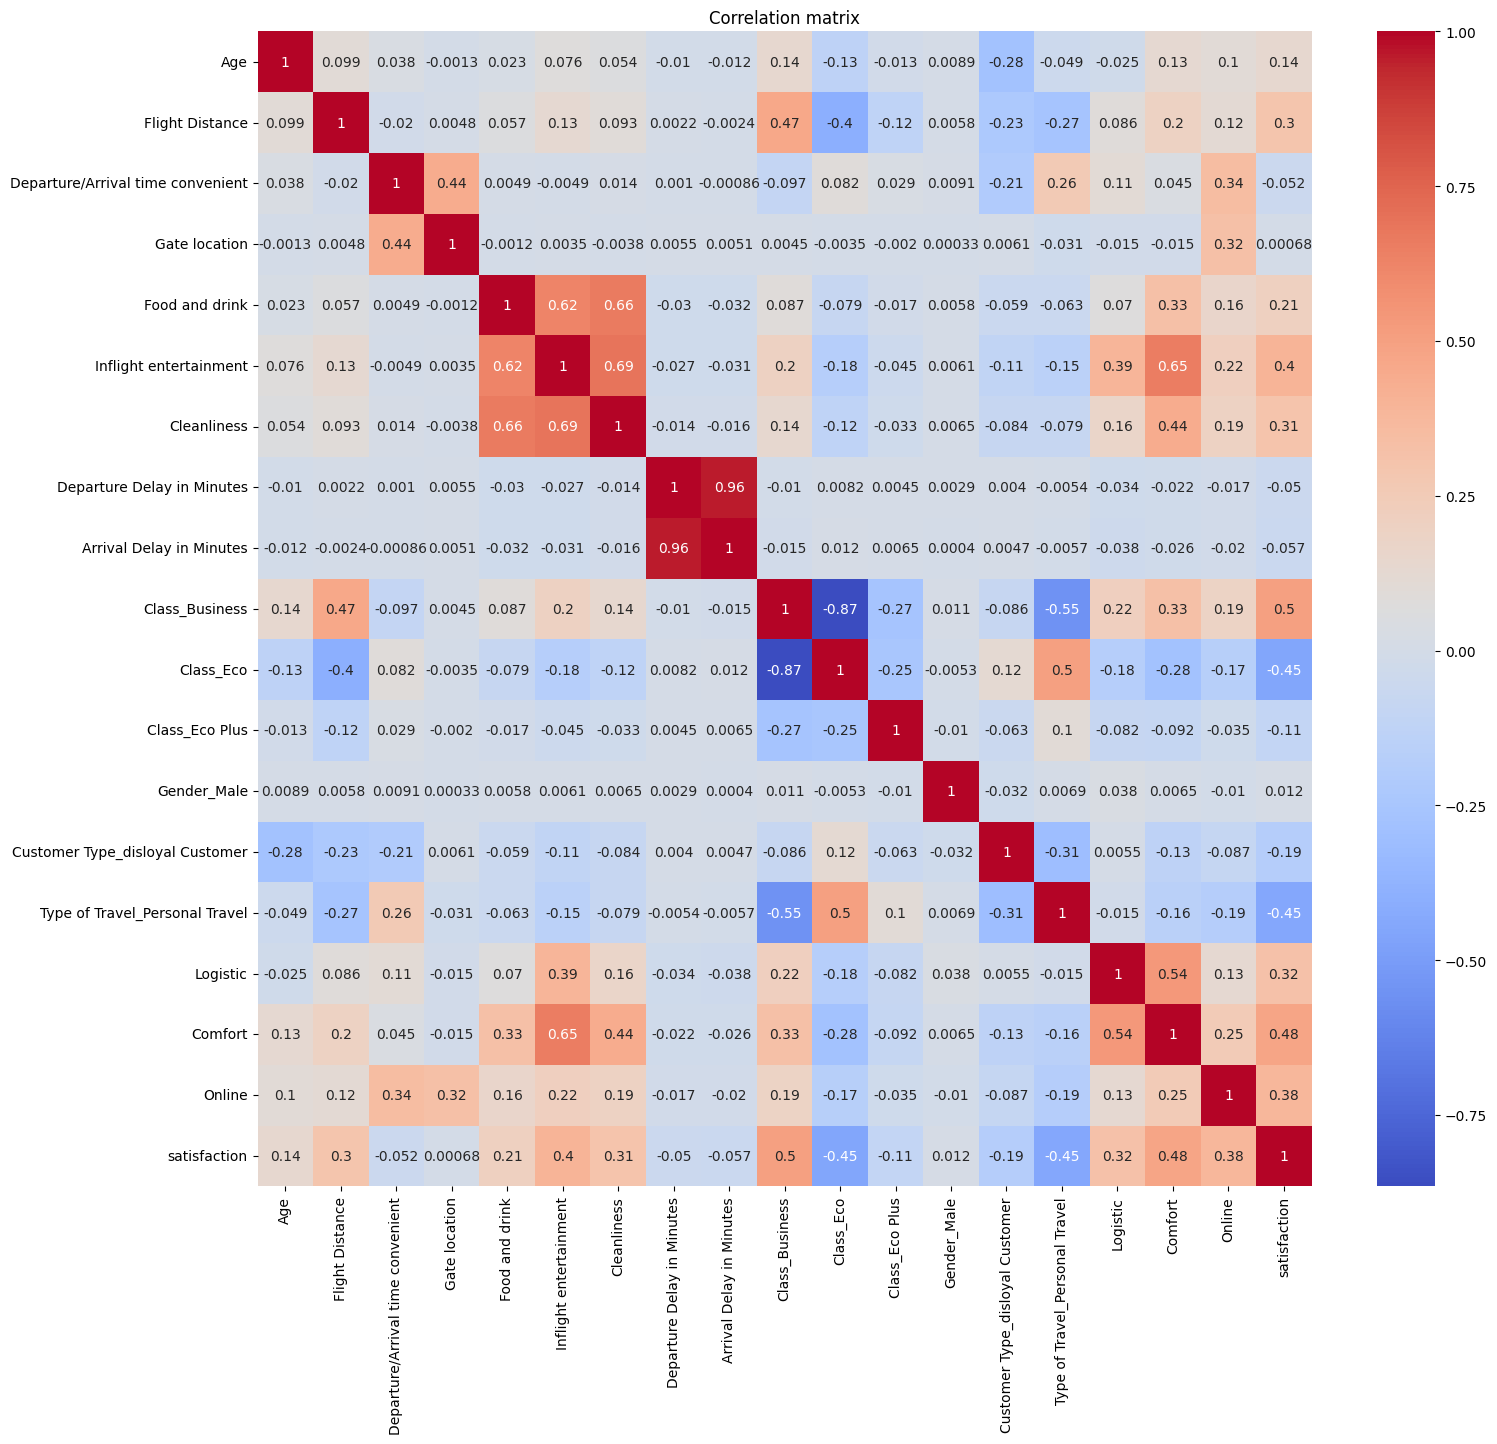

In [105]:
plt.figure(figsize=(17, 15))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

Mirant la correlació de cada caracterísitca amb la satisfacció del passatger s'ha decidit eliminar les següents columnes:

- *Departure/Arrival time convenient*
- *Gate location*
- *Departure Delay in Minutes", "Arrival Delay in Minutes*
- *Gender_Male*

Tot i que *Age* i *Customer Type* tenen una relació relativament baixa amb *satisfaction* s'ha decidit mantenir-les perque són característiques descriptores essencials dels passatgers:

- *Age*: qui és el passatger?
- *Customer Type*: el passatger té qualque tipus de relació amb l'aerolínea?

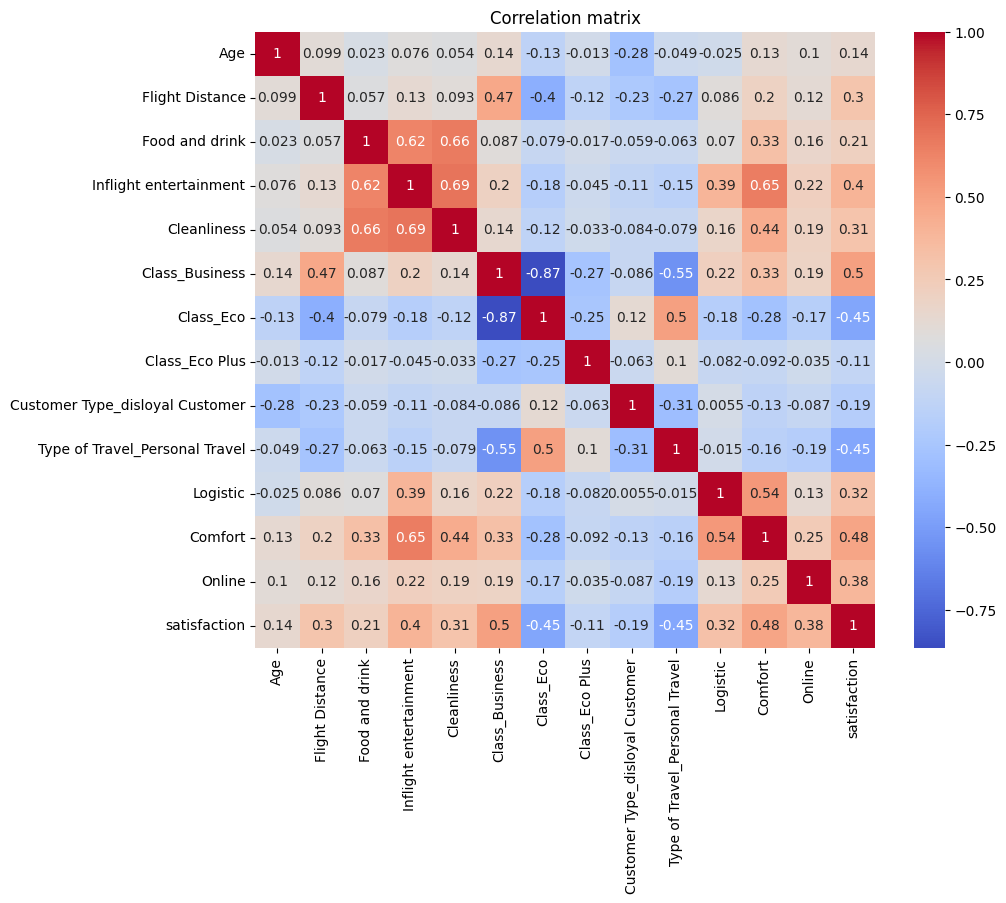

In [106]:
ignore = [
  "Departure/Arrival time convenient",
  "Gate location",
  "Departure Delay in Minutes", "Arrival Delay in Minutes",
  "Gender_Male",
]
X_train = X_train.drop(columns=ignore)
X_test = X_test.drop(columns=ignore)

plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

In [67]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (103904, 13)


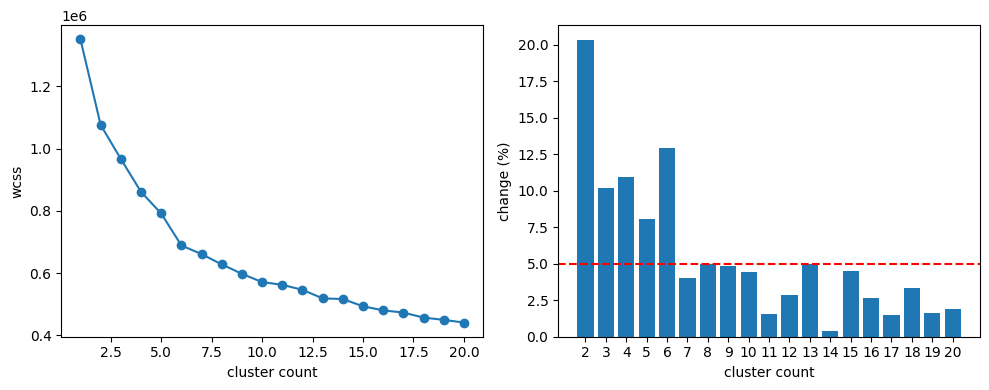

 1 ->  2 :  20.34%
 2 ->  3 :  10.17%
 3 ->  4 :  10.92%
 4 ->  5 :   8.07%
 5 ->  6 :  12.96%
 6 ->  7 :   4.06%
 7 ->  8 :   4.97%
 8 ->  9 :   4.83%
 9 -> 10 :   4.44%
10 -> 11 :   1.54%
11 -> 12 :   2.86%
12 -> 13 :   5.01%
13 -> 14 :   0.41%
14 -> 15 :   4.52%
15 -> 16 :   2.62%
16 -> 17 :   1.52%
17 -> 18 :   3.37%
18 -> 19 :   1.60%
19 -> 20 :   1.92%


In [71]:
from sklearn.cluster import KMeans

cnt = np.arange(1, 20 + 1)
wcss = np.zeros(len(cnt))
for i in cnt:
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X_train_scaled)
  wcss[i-1] = kmeans.inertia_

change_cnt = np.concat([cnt[:-1].reshape(-1, 1), cnt[1:].reshape(-1, 1)], axis=1)
change_pct = (wcss[:-1] - wcss[1:]) / wcss[:-1] * 100

fig, (ax_wcss, ax_change) = plt.subplots(1, 2, figsize=(5 * 2, 4))

ax_wcss.plot(cnt, wcss, marker="o")
ax_wcss.set_xlabel("cluster count")
ax_wcss.set_ylabel("wcss")

ax_change.bar(cnt[1:], change_pct)
ax_change.set_xticks(cnt[1:])
ax_change.set_xlabel("cluster count")
ax_change.set_ylabel("change (%)")
ax_change.axhline(y=5, color="red", linestyle="--")

plt.tight_layout()
plt.show()

for (c1, c2), p in zip(change_cnt, change_pct): print(f"{c1:2d} -> {c2:2d} : {p:6.2f}%")

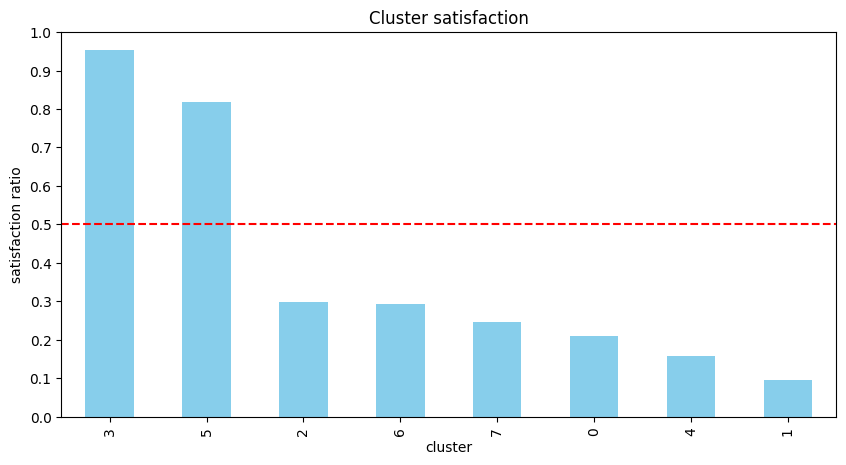

In [74]:
kmeans = KMeans(n_clusters=8, random_state=42)
cluster = pd.concat([X_train, y_train], axis=1)
cluster["cluster"] = kmeans.fit_predict(X_train_scaled)

satisfaction_per_cluster = cluster.groupby("cluster")["satisfaction"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
satisfaction_per_cluster.plot(kind="bar", color="skyblue")
plt.axhline(y=0.5, color="red", linestyle="--")
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.title("Cluster satisfaction")
plt.ylabel("satisfaction ratio")
plt.show()

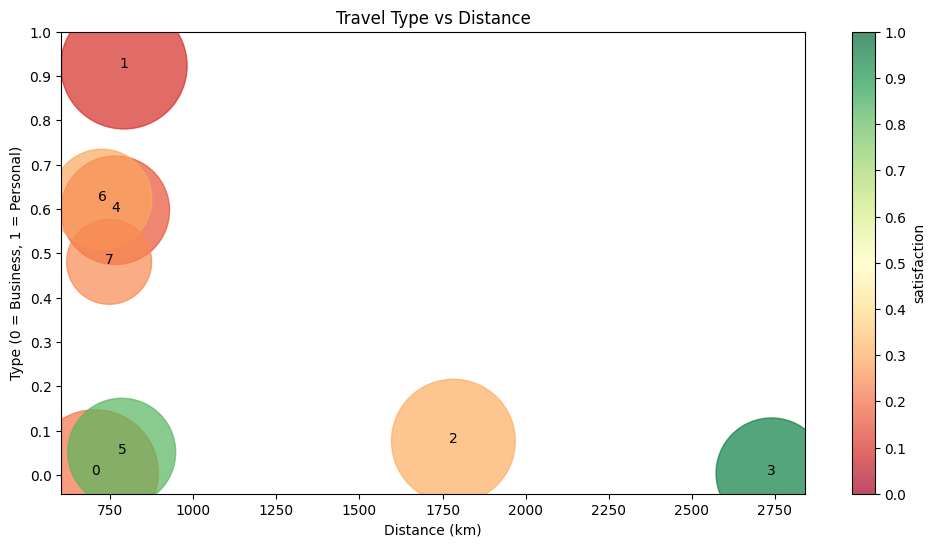

In [75]:
summary = cluster.groupby("cluster").mean()

from matplotlib.axes import Axes
from matplotlib.figure import Figure

def summary_scatter(fig: Figure, ax: Axes, xcol: str, ycol: str, x = None, y = None):
  if x is None: x = summary[xcol]
  if y is None: y = summary[ycol]
  scat = ax.scatter(x, y,
             s=cluster["cluster"].value_counts() * 0.5, c=summary["satisfaction"],
             vmin=0.00, vmax=1.00,
             cmap="RdYlGn", alpha=0.70)
  for i, txt in enumerate(summary.index):
    x, y = summary[xcol][i], summary[ycol][i]
    ax.annotate(txt, xy=(x, y), xytext=(-3, -3), textcoords="offset points", ha="left", va="bottom")
  cbar = fig.colorbar(scat, label="satisfaction")
  cbar.set_ticks(np.arange(0, 1.1, 0.1)) # type: ignore

fig, ax = plt.subplots(figsize=(12, 6))
summary_scatter(fig, ax, "Flight Distance", "Type of Travel_Personal Travel")
ax.set_title("Travel Type vs Distance")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Type (0 = Business, 1 = Personal)")
ax.set_yticks(np.arange(0, 1.10, 0.10))
plt.show()

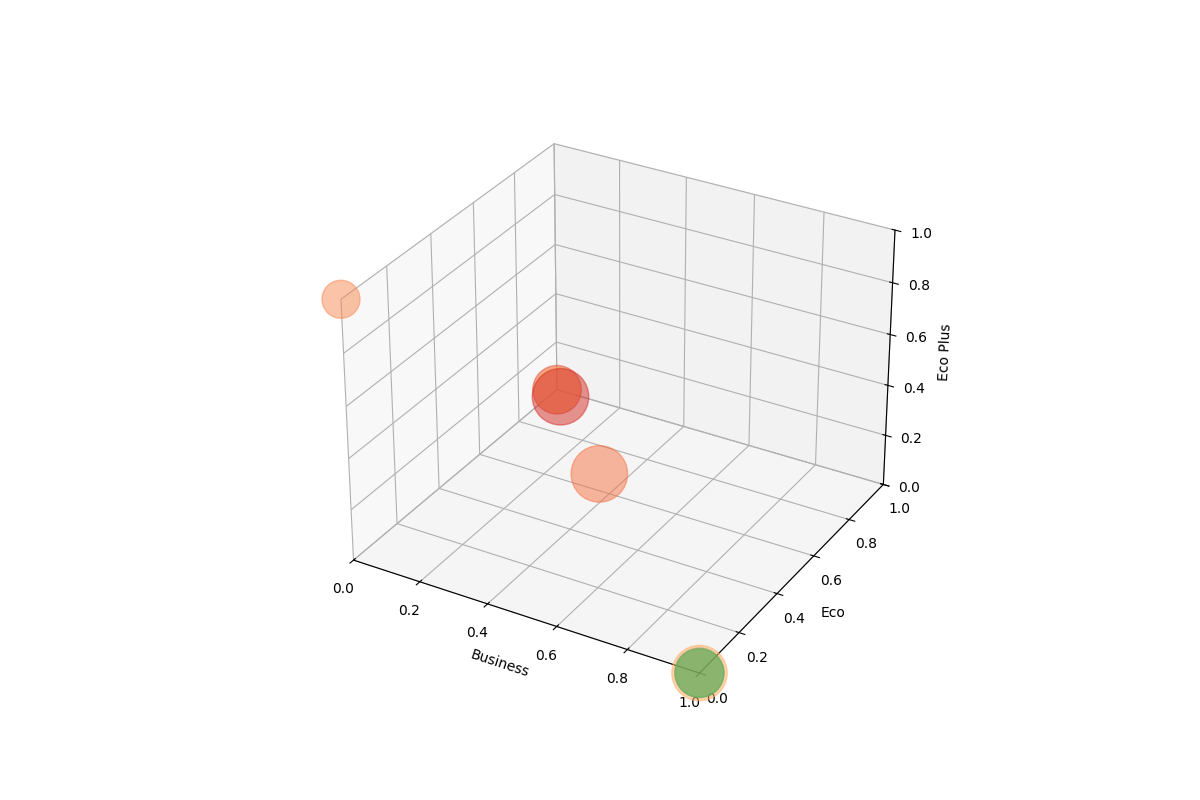

In [76]:
%matplotlib widget

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")

x, y, z = summary["Class_Business"], summary["Class_Eco"], summary["Class_Eco Plus"]
ax.scatter(x, y, z, c=summary["satisfaction"], cmap="RdYlGn", alpha=0.5, vmin=0.00, vmax=1.00, s=cluster["cluster"].value_counts() * 0.1)
ax.set_xlabel("Business")
ax.set_ylabel("Eco")
ax.set_zlabel("Eco Plus")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
plt.show()

In [77]:
%matplotlib inline
plt.close(fig)

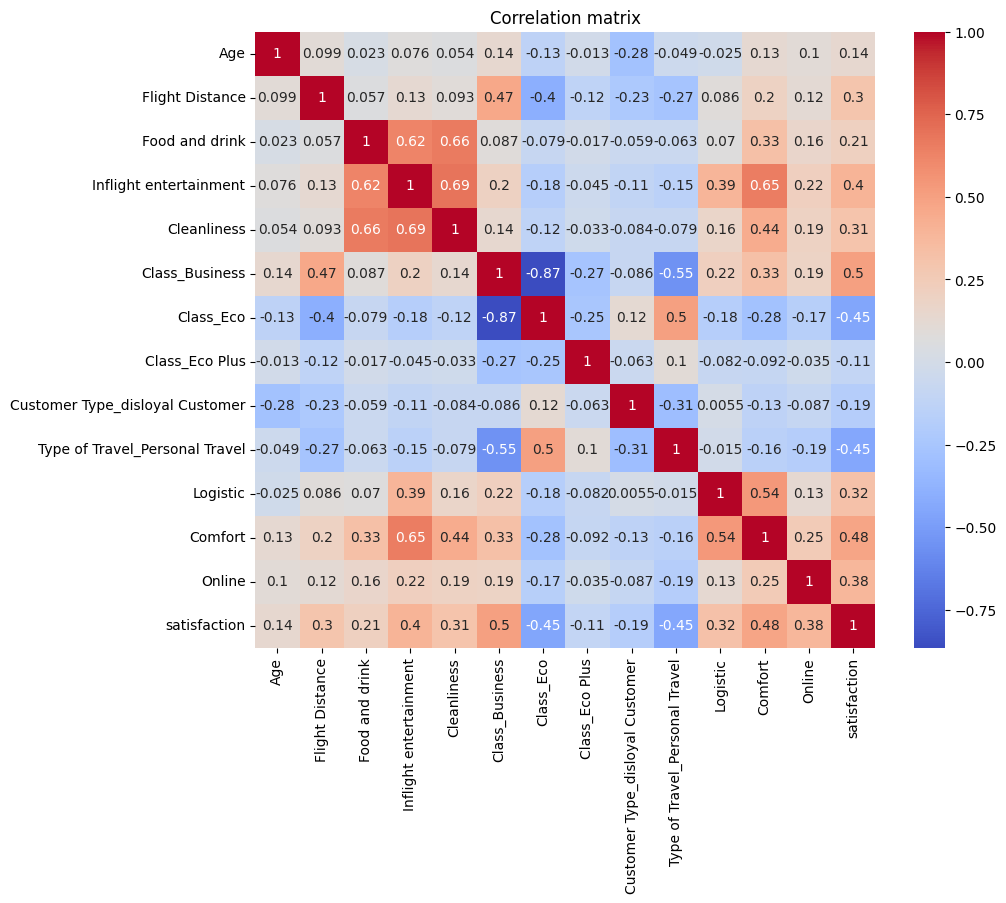

In [78]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

In [89]:
summary[summary["Class_Business"] > 0.5]
# summary["Class_Business"]
# summary
# xlabel, ylabel = "Flight comfort (mean)", "Online service (mean)"
# x, y = summary[xlabel], summary[ylabel]
# x /= x.max()
# y /= y.max()

# fig, ax = plt.subplots(figsize=(12, 6))
# summary_scatter(fig, ax, xlabel, ylabel, x, y)
# # ax.set_title("Travel Type vs Class Eco")
# ax.set_xlabel("Flight comfort (%)")
# ax.set_ylabel("Online service")
# # ax.set_yticks(np.arange(0, 1.10, 0.10))
# plt.show()

,Flight Distance,Checkin service,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,Flight comfort (mean),Flight service (mean),Ease of use (mean),satisfaction
cluster,,,,,,,,,,
0,1647.125341,2.550251,0.086001,1.000000,0.000000,0.0,2.721447,2.589017,2.773266,0.284996
3,1546.364274,3.918494,0.028937,1.000000,0.000000,0.0,3.813900,4.222286,2.168800,0.790311
5,1818.548141,3.877324,0.022227,0.999947,0.000053,0.0,3.931663,4.193030,4.079301,0.913390


# Training

In [83]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
  "Perceptron": Perceptron(max_iter=1000),
  "Logistic Regression": LogisticRegression(max_iter=1000),
  "SVM": SVC(max_iter=1000),
  "Tree": DecisionTreeClassifier(),
  "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
  print(f"******** {name} ********")

  model.fit(X_train_scaled, y_train)

  y_train_pred = model.predict(X_train_scaled)
  y_test_pred = model.predict(X_test_scaled)

  acc_train = accuracy_score(y_train, y_train_pred)
  acc_test = accuracy_score(y_test, y_test_pred)

  print(f"train acc: {acc_train:6.4f}")
  print(f" test acc: {acc_test:6.4f}")

  if acc_train - acc_test > 0.1: print("WARNING: possible overfitting")

  print()

******** Perceptron ********
train acc: 0.8191
 test acc: 0.8178

******** Logistic Regression ********
train acc: 0.8342
 test acc: 0.8267

******** SVM ********


/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


train acc: 0.3570
 test acc: 0.3605

******** Tree ********
train acc: 0.9996
 test acc: 0.8299

******** Random Forest ********
train acc: 0.9995
 test acc: 0.8711

